In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
X_test.shape

(10000, 28, 28)

In [7]:
y_test.shape

(10000,)

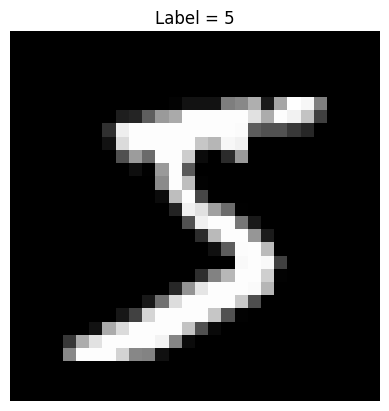

In [8]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label = {y_train[0]}")
plt.axis('off')
plt.show()

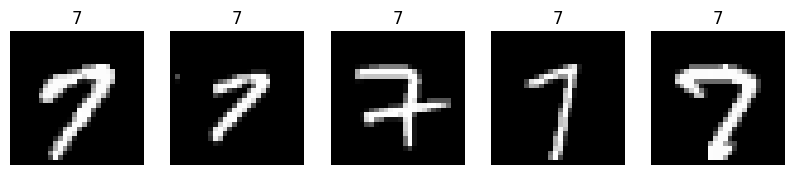

In [9]:
import matplotlib.pyplot as plt
import numpy as np

seven_indices = np.where(y_train == 7)[0]

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[seven_indices[i]], cmap='gray')
    plt.title("7")
    plt.axis('off')

plt.show()

In [10]:
import numpy as np

TARGET_DIGIT = 7

count_7 = np.sum(y_train == TARGET_DIGIT)

print("Number of 7s in training set:", count_7)

Number of 7s in training set: 6265


In [11]:
y_train_binary = (y_train == 7).astype(int)
y_test_binary = (y_test == 7).astype(int)

print("Original labels:")
print(y_train[:20])

print("\nBinary labels:")
print(y_train_binary[:20])

Original labels:
[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]

Binary labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [12]:
print("Number of positive examples:", y_train_binary.sum())

Number of positive examples: 6265


In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [15]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,345 (474.00 KB)

 Trainable params: 121,345 (474.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    X_train,
    y_train_binary,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9859 - loss: 0.0400 - val_accuracy: 0.9952 - val_loss: 0.0164
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9951 - loss: 0.0151 - val_accuracy: 0.9964 - val_loss: 0.0118
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9960 - loss: 0.0109 - val_accuracy: 0.9976 - val_loss: 0.0070
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9977 - loss: 0.0076 - val_accuracy: 0.9980 - val_loss: 0.0066
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9977 - val_loss: 0.0061
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9983 - loss: 0.0049 - val_accuracy: 0.9983 - val_loss: 0.0051
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9985 - loss: 0.0041 - val_accuracy: 0.9977 - val_loss: 0.0078
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9989 - loss: 0.0033 -

In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_binary
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9971 - loss: 0.0111
Test Accuracy: 0.9970999956130981


In [20]:
import numpy as np

# Indices of digit 7
seven_idx = np.where(y_test == 7)[0]

# Indices of non-7 digits
non_seven_idx = np.where(y_test != 7)[0]

# Randomly select
selected_7 = np.random.choice(seven_idx, 5, replace=False)
selected_non7 = np.random.choice(non_seven_idx, 5, replace=False)

selected_indices = np.concatenate([selected_7, selected_non7])

np.random.shuffle(selected_indices)

print(selected_indices)

[7902 1776 6197 4322  751 9899 6497 2270 6788 9716]


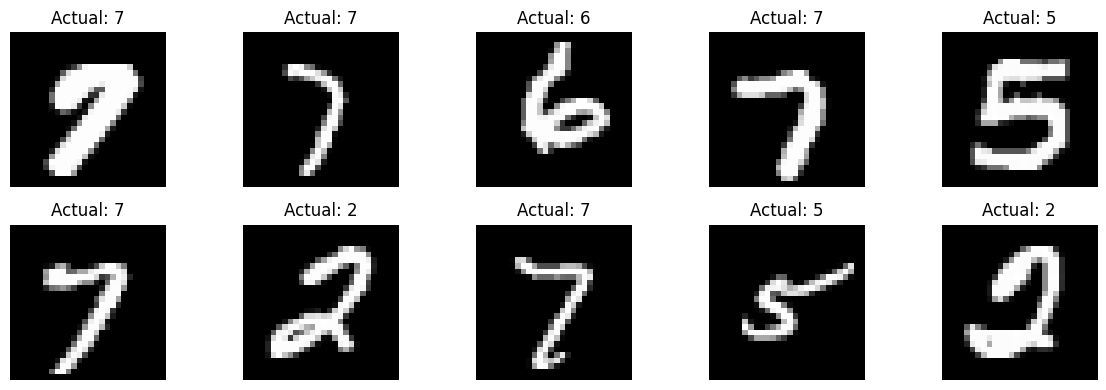

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

for i, idx in enumerate(selected_indices):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {y_test[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
predictions = model.predict(X_test[selected_indices])

for i, idx in enumerate(selected_indices):

    actual_digit = y_test[idx]
    actual_class = "7" if actual_digit == 7 else "Not 7"

    probability = predictions[i][0]

    predicted_class = "7" if probability >= 0.5 else "Not 7"

    print(f"Image {i+1}")
    print(f"Actual Digit      : {actual_digit}")
    print(f"Actual Class      : {actual_class}")
    print(f"Prediction Score  : {probability:.4f}")
    print(f"Predicted Class   : {predicted_class}")
    print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
Image 1
Actual Digit      : 7
Actual Class      : 7
Prediction Score  : 0.9994
Predicted Class   : 7
----------------------------------------
Image 2
Actual Digit      : 7
Actual Class      : 7
Prediction Score  : 0.9974
Predicted Class   : 7
----------------------------------------
Image 3
Actual Digit      : 6
Actual Class      : Not 7
Prediction Score  : 0.0000
Predicted Class   : Not 7
----------------------------------------
Image 4
Actual Digit      : 7
Actual Class      : 7
Prediction Score  : 1.0000
Predicted Class   : 7
----------------------------------------
Image 5
Actual Digit      : 5
Actual Class      : Not 7
Prediction Score  : 0.0000
Predicted Class   : Not 7
----------------------------------------
Image 6
Actual Digit      : 7
Actual Class      : 7
Prediction Score  : 1.0000
Predicted Class   : 7
----------------------------------------
Image 7
Actual Digit      : 2
Actual Class      : Not 7
Prediction Score  : 0.0000
Predicted 

In [23]:
correct = 0

for i, idx in enumerate(selected_indices):

    actual = 1 if y_test[idx] == 7 else 0
    predicted = 1 if predictions[i][0] >= 0.5 else 0

    if actual == predicted:
        correct += 1

print(f"Correct Predictions: {correct}/10")
print(f"Accuracy on Sample Set: {correct*10}%")

Correct Predictions: 10/10
Accuracy on Sample Set: 100%


Save the model

In [25]:
model.save("digitone_model.h5")

In [26]:
import os

print(os.path.exists("digitone_model.h5"))

True


Training Graph

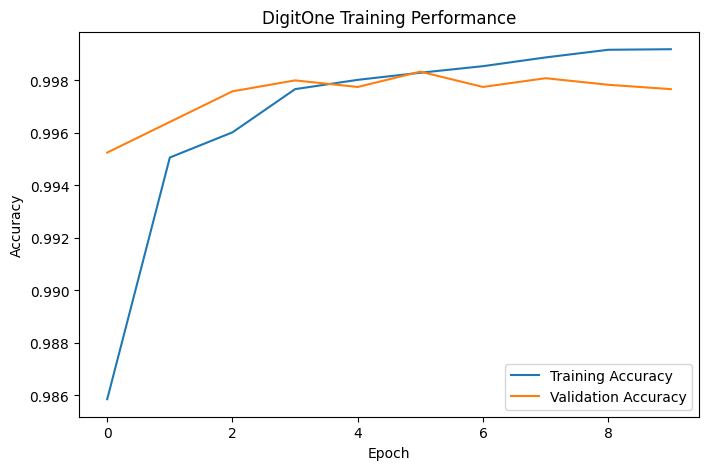

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('DigitOne Training Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

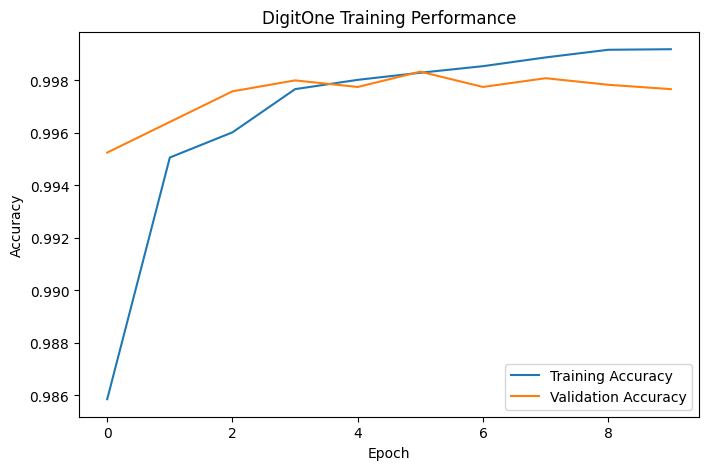

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('DigitOne Training Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("training_accuracy.png", bbox_inches='tight')

plt.show()

PROJECT SUMMARY!!

# DigitOne

High-Accuracy Single-Digit Recognition using CNN

## Target Digit
7

## Dataset
MNIST

## Model
Convolutional Neural Network (CNN)

## Training Strategy
80-20 Train-Validation Split

## Results

Training Accuracy: 99.92%

Validation Accuracy: 99.77%

Test Accuracy: 99.71%

Custom Test Set:
10/10 Correct Predictions
100% Accuracy

## Objective

Detect whether a handwritten digit is 7 or not 7.